<a href="https://colab.research.google.com/github/Mayuri0320/Datax504-Mayuri/blob/main/a4_convnet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 4 — CIFAR-10 ConvNet

**DATAX504** · Due end of Week 8

Build on **Chapter 8** (ConvNets, augmentation) and ideas from **Chapters 9–10** (interpretation). You design the stack; the goal is a working pipeline you can explain, not a copy of a tutorial.

## Tasks
1. Load CIFAR-10, normalise, create a train / validation split
2. Build a **data augmentation** pipeline used during training
3. Train a **ConvNet** that reaches **>65%** test accuracy
4. Visualise at least one filter / feature (layer weights or activation-based)
5. Brief interpretation of what that filter responds to (Moodle `a4_interpretation`)

## Moodle fields
`a4_repo`, `a4_test_acc`, `a4_filter_layer`, `a4_interpretation`

## AI disclosure (required)
Fill the table in the next cell before you submit.


## AI disclosure

| Field | Your answer |
|-------|-------------|
| Tool / model | |
| Used for | |
| Verified how | |
| Not used for | |


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import keras
from keras import layers


## 1. Load & prepare CIFAR-10

Hints:
- `keras.datasets.cifar10.load_data()`
- cast pixels to float and scale to `[0, 1]` (or another range you document)
- flatten label shape if needed (`y.ravel()`)
- hold out a validation slice from the training set (e.g. last 5_000 or 10_000)


In [ ]:
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
]

(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

y_train = y_train.ravel()
y_test = y_test.ravel()

VAL_SIZE = 5000
x_val = x_train[-VAL_SIZE:]
y_val = y_train[-VAL_SIZE:]
x_train = x_train[:-VAL_SIZE]
y_train = y_train[:-VAL_SIZE]

print("train:", getattr(x_train, "shape", None), getattr(y_train, "shape", None))
print("val:  ", getattr(x_val, "shape", None), getattr(y_val, "shape", None))
print("test: ", getattr(x_test, "shape", None), getattr(y_test, "shape", None))



train: (45000, 32, 32, 3) (45000,)
val:   (5000, 32, 32, 3) (5000,)
test:  (10000, 32, 32, 3) (10000,)


## 2. Data augmentation

Build a small `keras.Sequential` of image layers (e.g. flip / rotation / zoom).
Apply it **inside** the model (or as a preprocessing layer) so training sees augmented batches.

Preview a few transforms on one training image to check it works.


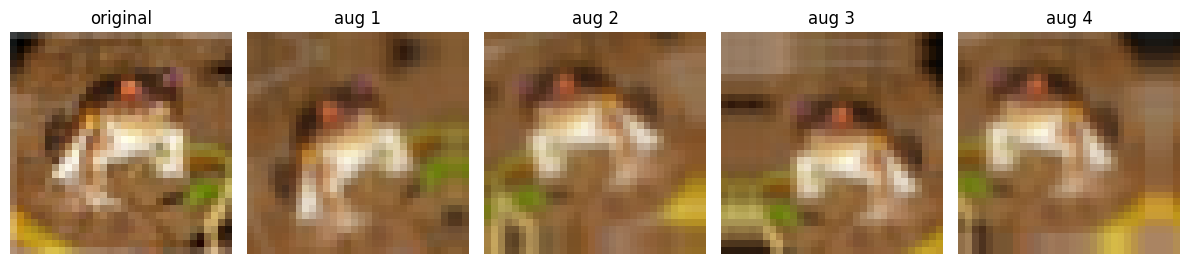

In [ ]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.08),
        layers.RandomZoom(0.1),
        layers.RandomTranslation(0.1, 0.1),
    ],
    name="augmentation",
)

sample = x_train[0:1]
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
axes[0].imshow(sample[0])
axes[0].set_title("original")
axes[0].axis("off")
for i in range(1, 5):
    augmented = data_augmentation(sample, training=True)
    axes[i].imshow(np.clip(augmented[0].numpy(), 0, 1))
    axes[i].set_title(f"aug {i}")
    axes[i].axis("off")
plt.tight_layout()
plt.show()

## 3. ConvNet model

Requirements:
- Input shape `(32, 32, 3)`
- Include your augmentation as the first stage of the graph (training only behaviour is fine)
- At least two `Conv2D` + pooling stages, then a dense classifier for 10 classes
- Name at least one early conv layer (you will need the name for visualisation)

Compile with a suitable loss for integer class labels (or one-hot — be consistent).


In [ ]:
inputs = keras.Input(shape=(32, 32, 3))
x = data_augmentation(inputs)

# Block 1
x = layers.Conv2D(32, 3, padding="same", activation="relu", name="conv2d_1")(x)
x = layers.BatchNormalization()(x)
x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D(2)(x)
x = layers.Dropout(0.2)(x)

# Block 2
x = layers.Conv2D(64, 3, padding="same", activation="relu", name="conv2d_2")(x)
x = layers.BatchNormalization()(x)
x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D(2)(x)
x = layers.Dropout(0.3)(x)

# Block 3
x = layers.Conv2D(128, 3, padding="same", activation="relu", name="conv2d_3")(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D(2)(x)
x = layers.Dropout(0.4)(x)

# Classifier head
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(10, activation="softmax")(x)

model = keras.Model(inputs, outputs)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,29

 Total params: 158,506 (619.16 KB)

 Trainable params: 157,866 (616.66 KB)

 Non-trainable params: 640 (2.50 KB)

## 4. Train & evaluate

Fit with `validation_data`. Aim for **>65%** test accuracy (Moodle wants the percentage).
Plot train vs val accuracy if useful for your write-up.


Epoch 1/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 209s 290ms/step - accuracy: 0.3628 - loss: 1.7244 - val_accuracy: 0.4366 - val_loss: 1.5815 - learning_rate: 0.0010
Epoch 2/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 199s 282ms/step - accuracy: 0.4802 - loss: 1.4339 - val_accuracy: 0.4562 - val_loss: 1.6564 - learning_rate: 0.0010
Epoch 3/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 197s 275ms/step - accuracy: 0.5300 - loss: 1.3093 - val_accuracy: 0.5046 - val_loss: 1.4545 - learning_rate: 0.0010
Epoch 4/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 199s 283ms/step - accuracy: 0.5616 - loss: 1.2266 - val_accuracy: 0.5650 - val_loss: 1.2051 - learning_rate: 0.0010
Epoch 5/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 204s 290ms/step - accuracy: 0.5906 - loss: 1.1544 - val_accuracy: 0.5460 - val_loss: 1.4380 - learning_rate: 0.0010
Epoch 6/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 200s 284ms/step - accuracy: 0.6115 - loss: 1.1065 - val_accuracy: 0.5226 - val_loss: 1.4951 - learning_rate: 0.0010
Epoch 7/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 199s 282ms/step - accura

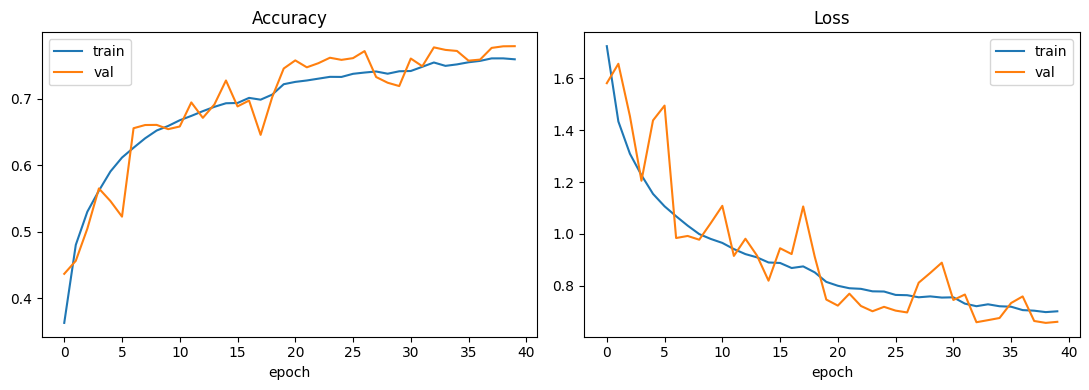

Test accuracy % (Moodle a4_test_acc): 76.56


In [ ]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=8, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6),
]

history = model.fit(
    x_train, y_train,
    epochs=40,
    batch_size=64,
    validation_data=(x_val, y_val),
    callbacks=callbacks,
    verbose=1,
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history.history["accuracy"], label="train")
axes[0].plot(history.history["val_accuracy"], label="val")
axes[0].set_title("Accuracy")
axes[0].set_xlabel("epoch")
axes[0].legend()

axes[1].plot(history.history["loss"], label="train")
axes[1].plot(history.history["val_loss"], label="val")
axes[1].set_title("Loss")
axes[1].set_xlabel("epoch")
axes[1].legend()
plt.tight_layout()
plt.show()

test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy % (Moodle a4_test_acc): {100 * test_acc:.2f}")

## 5. Filter visualisation

Pick a named conv layer (`a4_filter_layer`). Minimum expectation: plot first-layer filter weights as small images.

Optional deeper approach: gradient ascent / activation maximisation for one filter index (Ch 10 style).


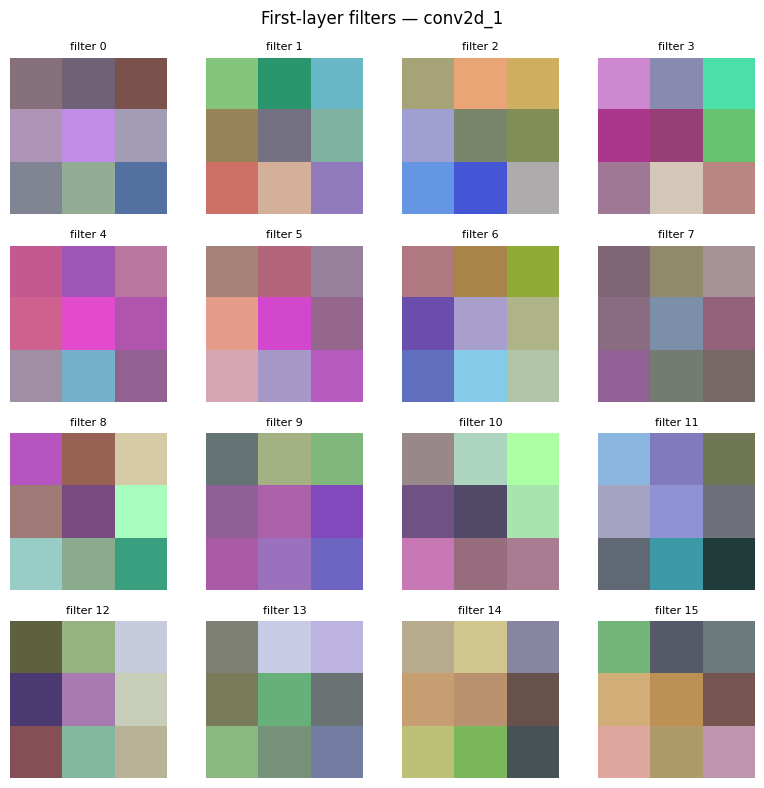

In [ ]:
VIS_LAYER = "conv2d_1"

conv_layer = model.get_layer(VIS_LAYER)
filters, biases = conv_layer.get_weights()

f_min, f_max = filters.min(), filters.max()
filters_norm = (filters - f_min) / (f_max - f_min + 1e-8)

n_filters = min(16, filters_norm.shape[-1])
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    if i < n_filters:
        ax.imshow(filters_norm[:, :, :, i])
        ax.set_title(f"filter {i}", fontsize=8)
    ax.axis("off")
plt.suptitle(f"First-layer filters — {VIS_LAYER}")
plt.tight_layout()
plt.show()

## 6. Interpretation (Moodle `a4_interpretation`)

Max ~200 words: what pattern does your chosen filter respond to?


I chose the conv2d_1 filter from the first convolutional layer. This filter responds mainly to simple patterns such as edges, changes in brightness, and colour transitions in the images. It can respond to edges in different directions, such as horizontal, vertical, or diagonal edges. These simple features are useful because the deeper layers can combine them to recognise more complex shapes and parts of objects.